## **Quarterly Loan Segment Numbers**

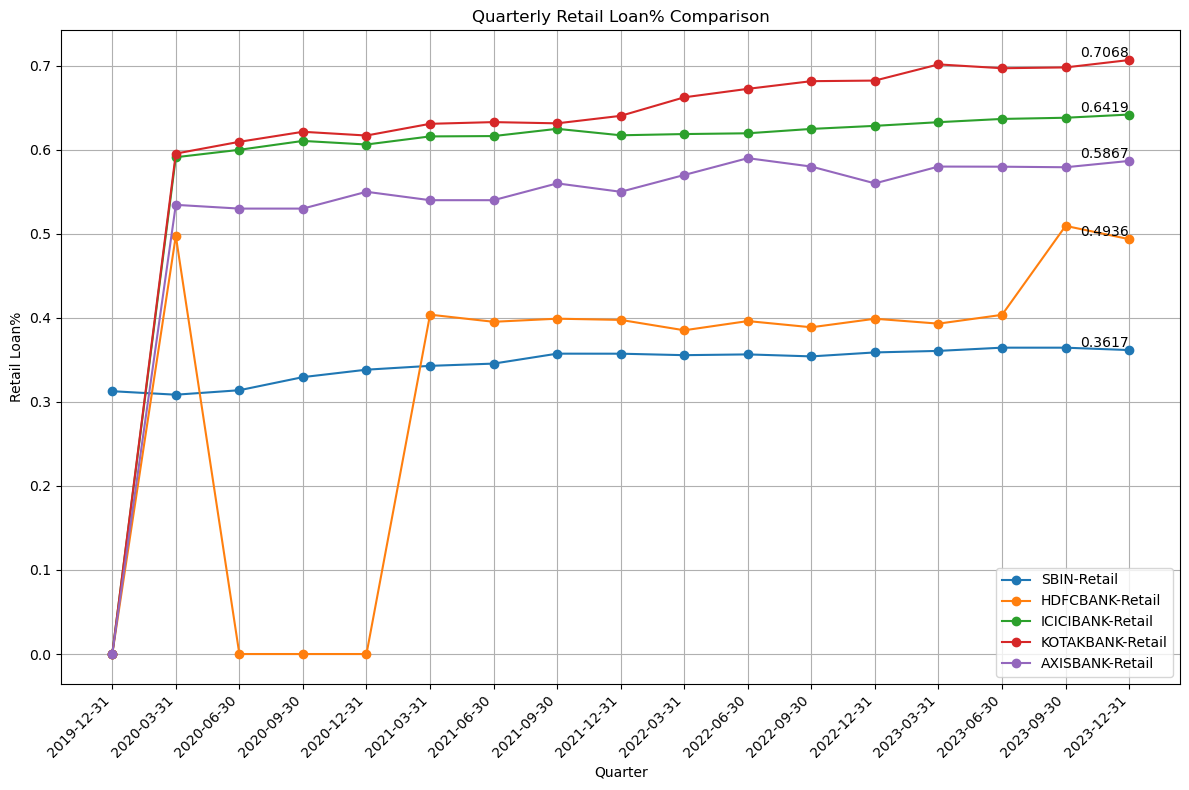

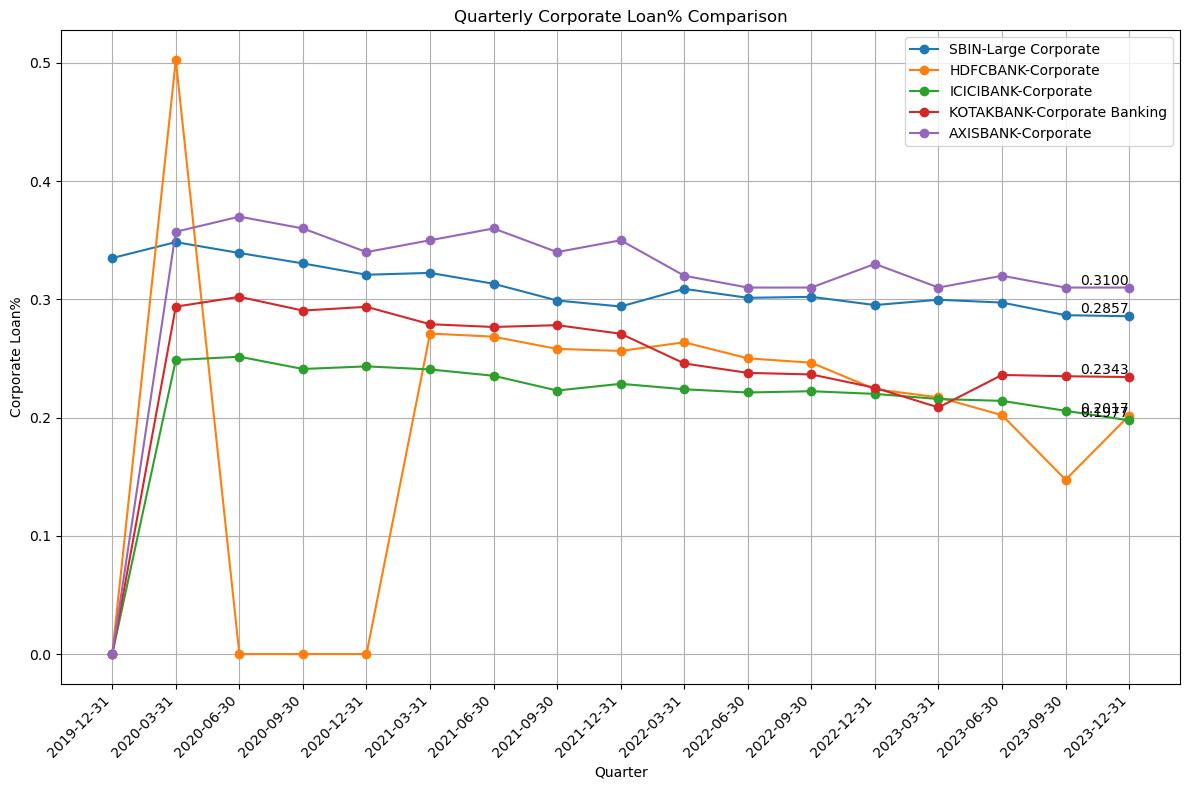

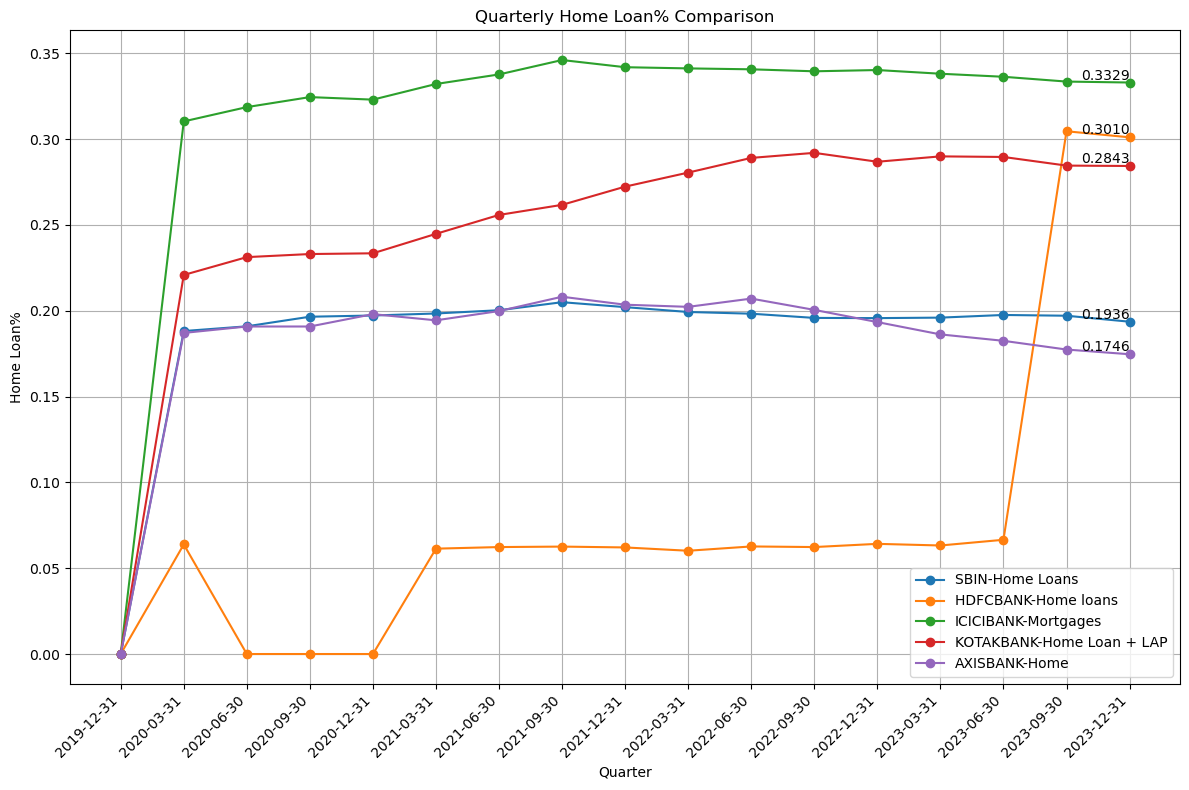

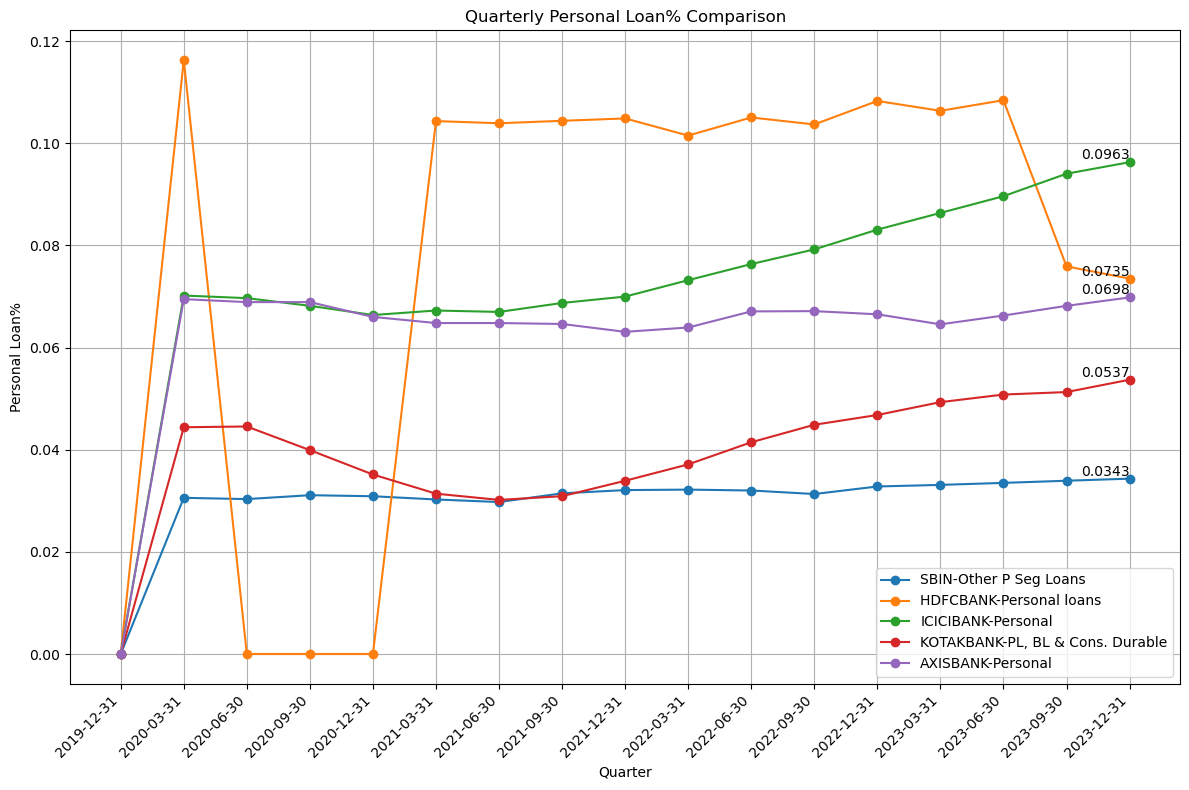

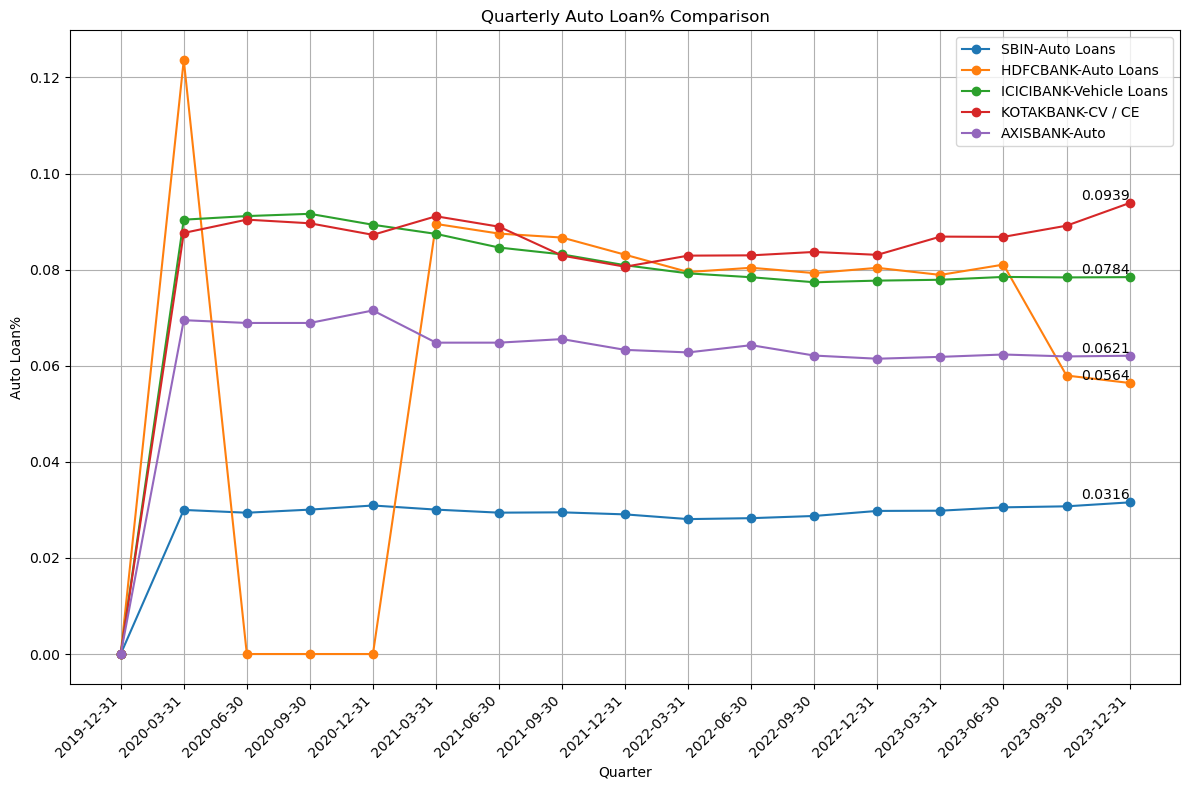

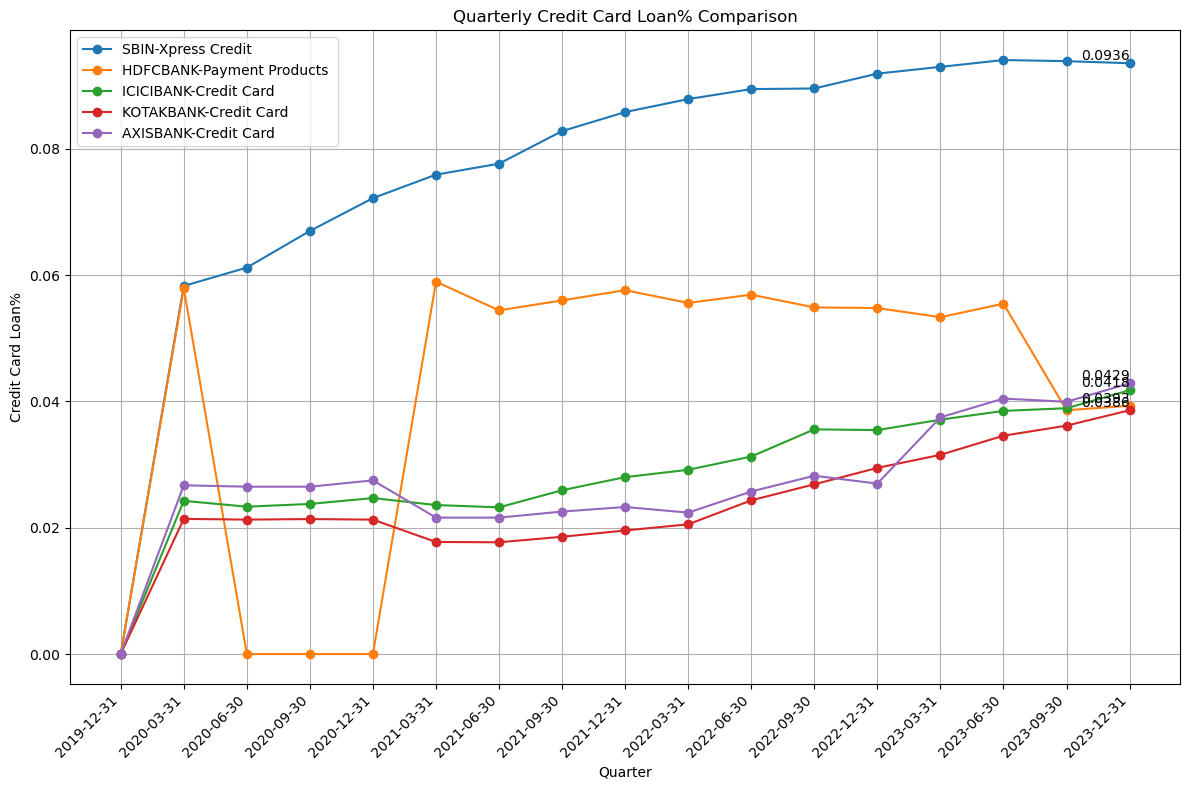

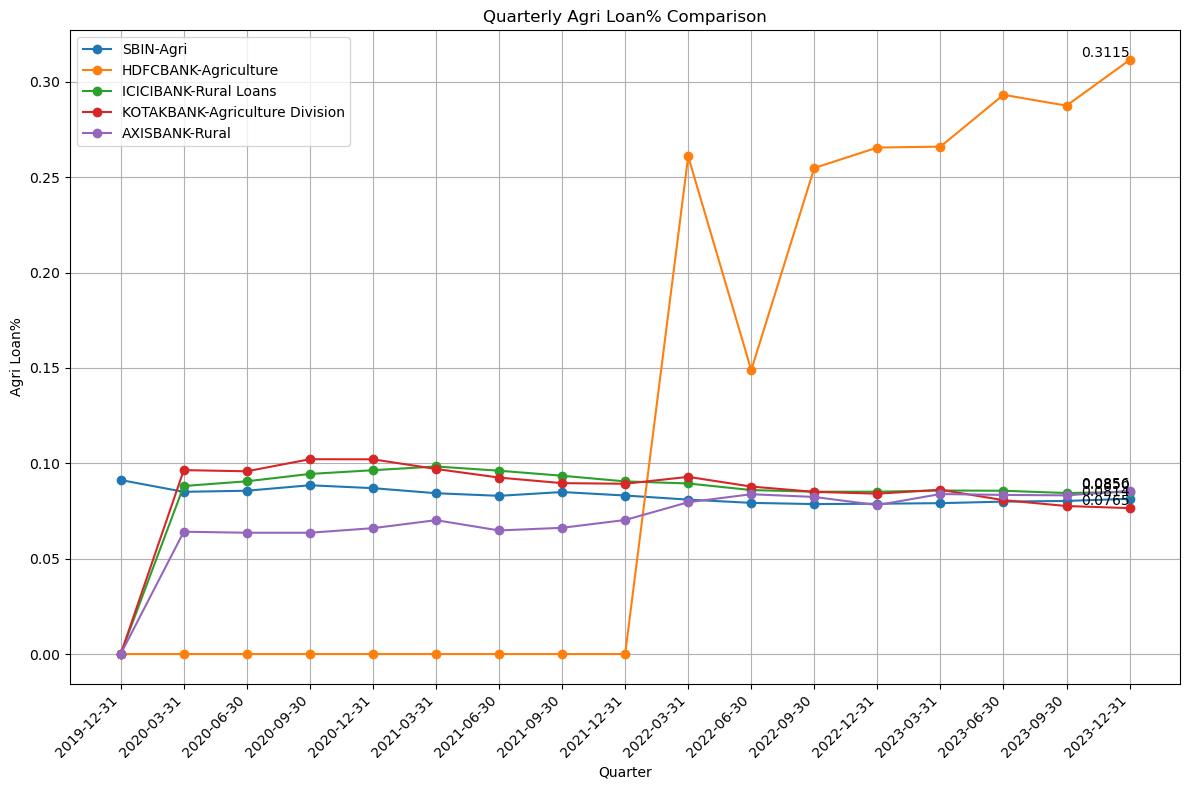

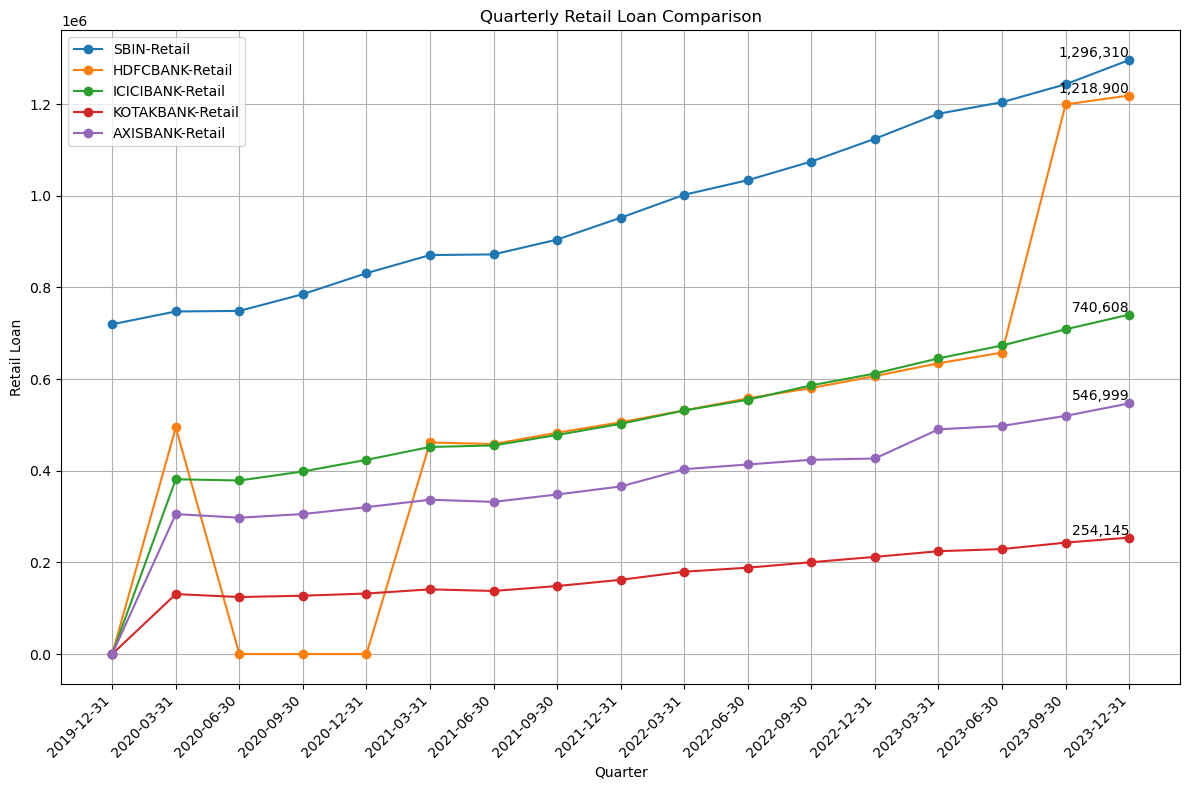

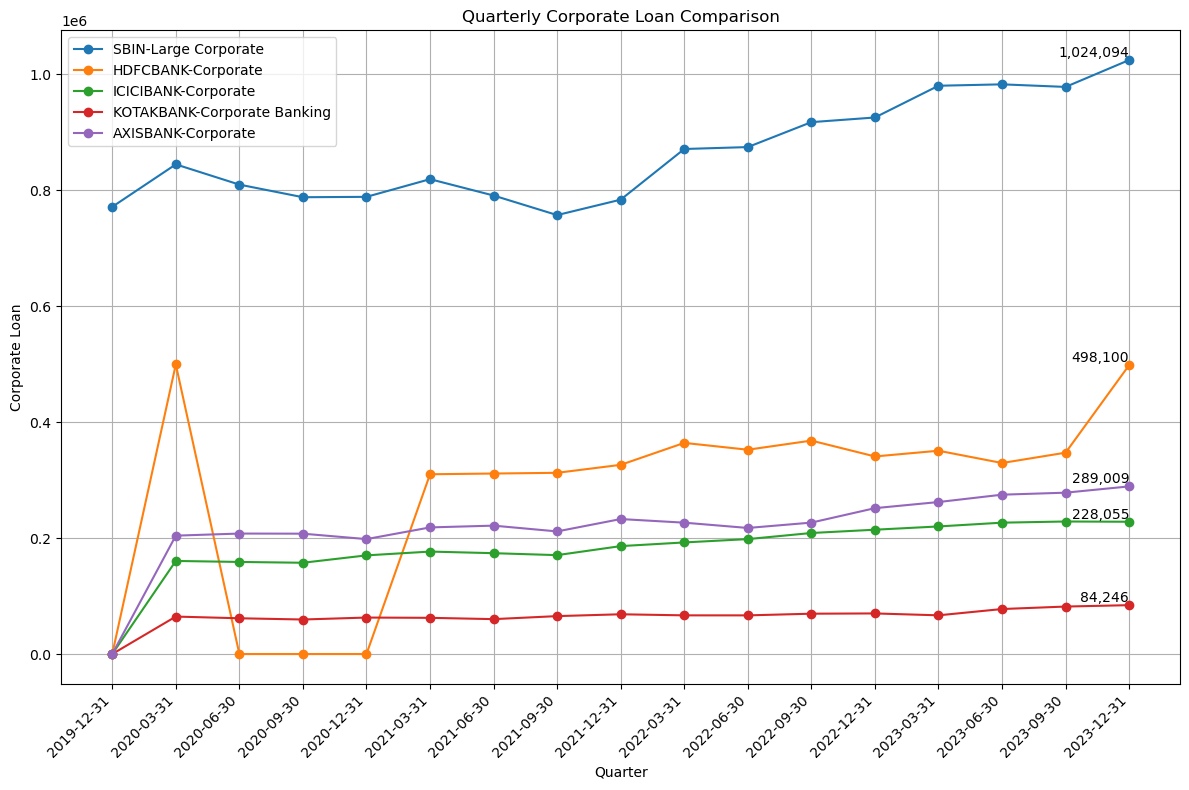

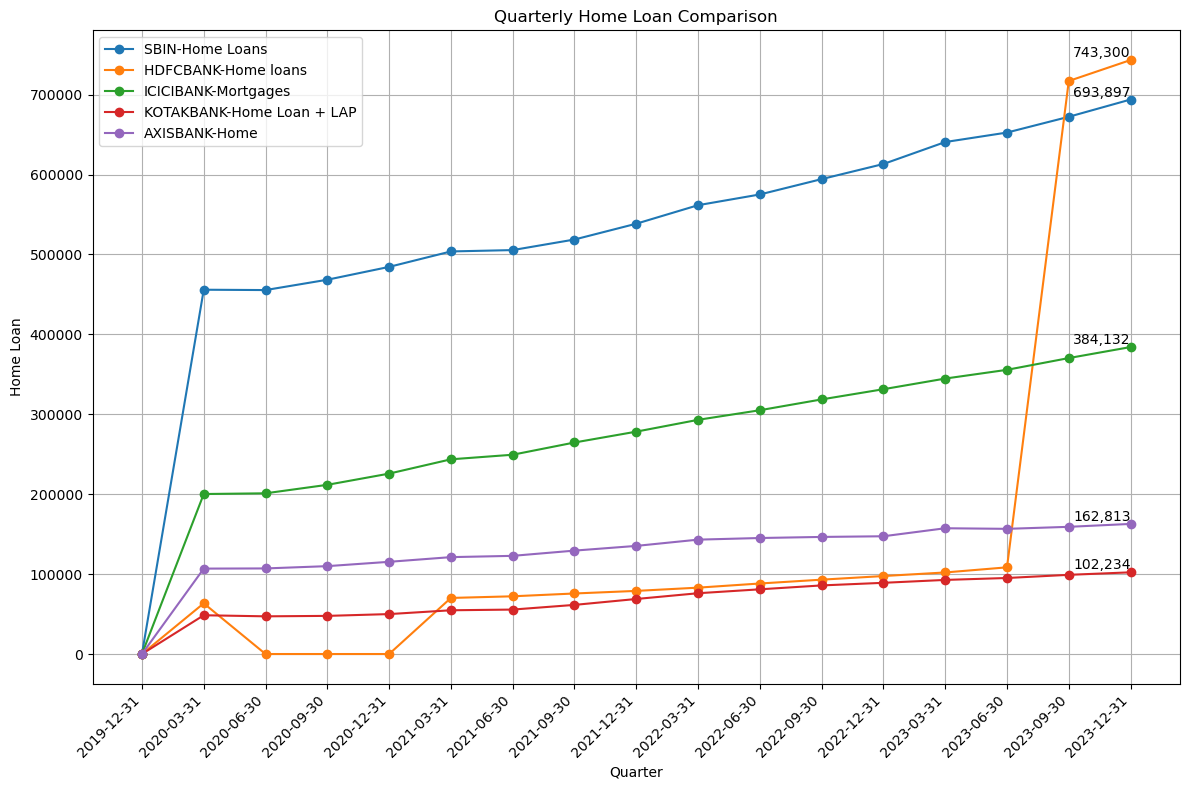

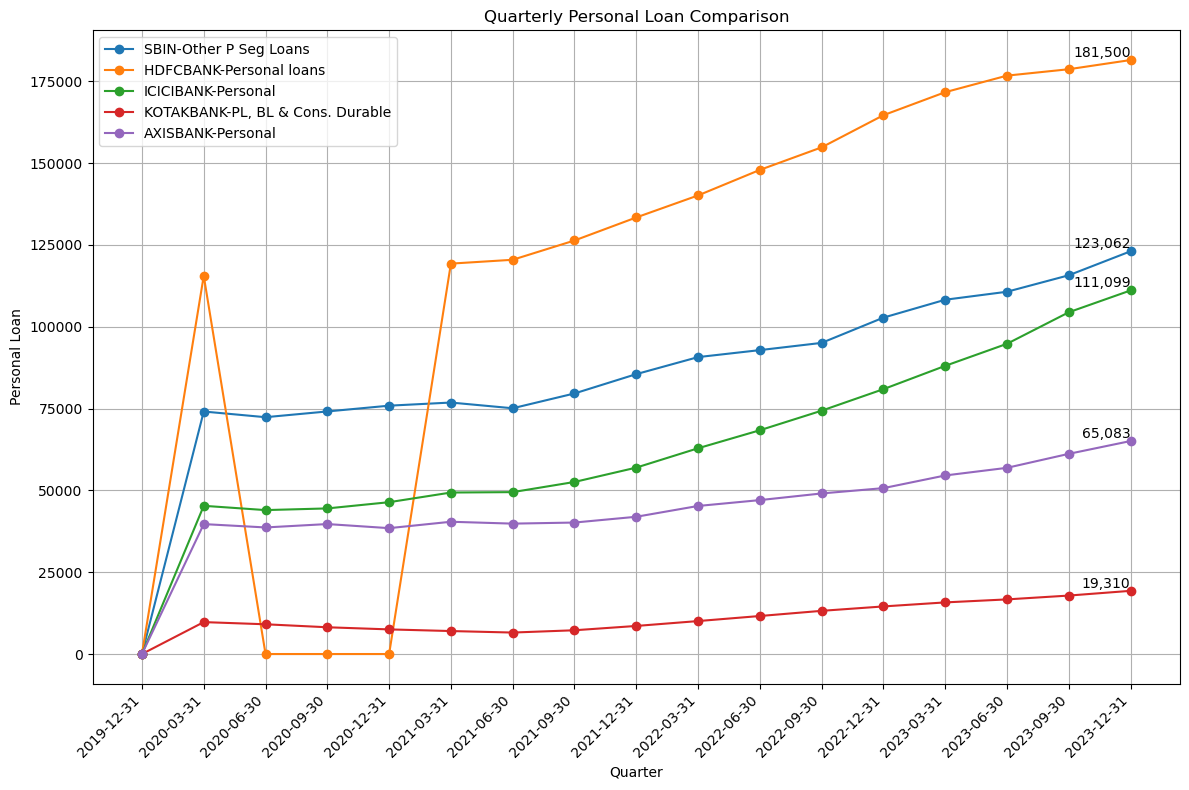

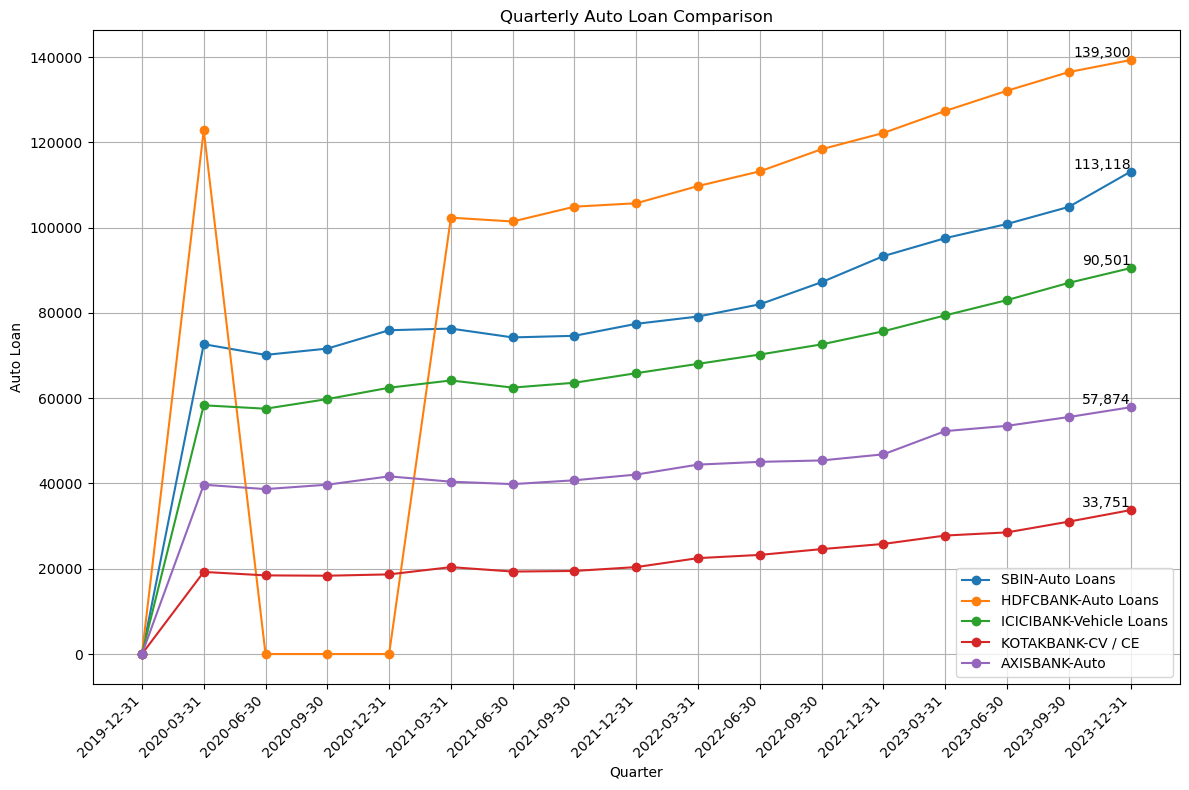

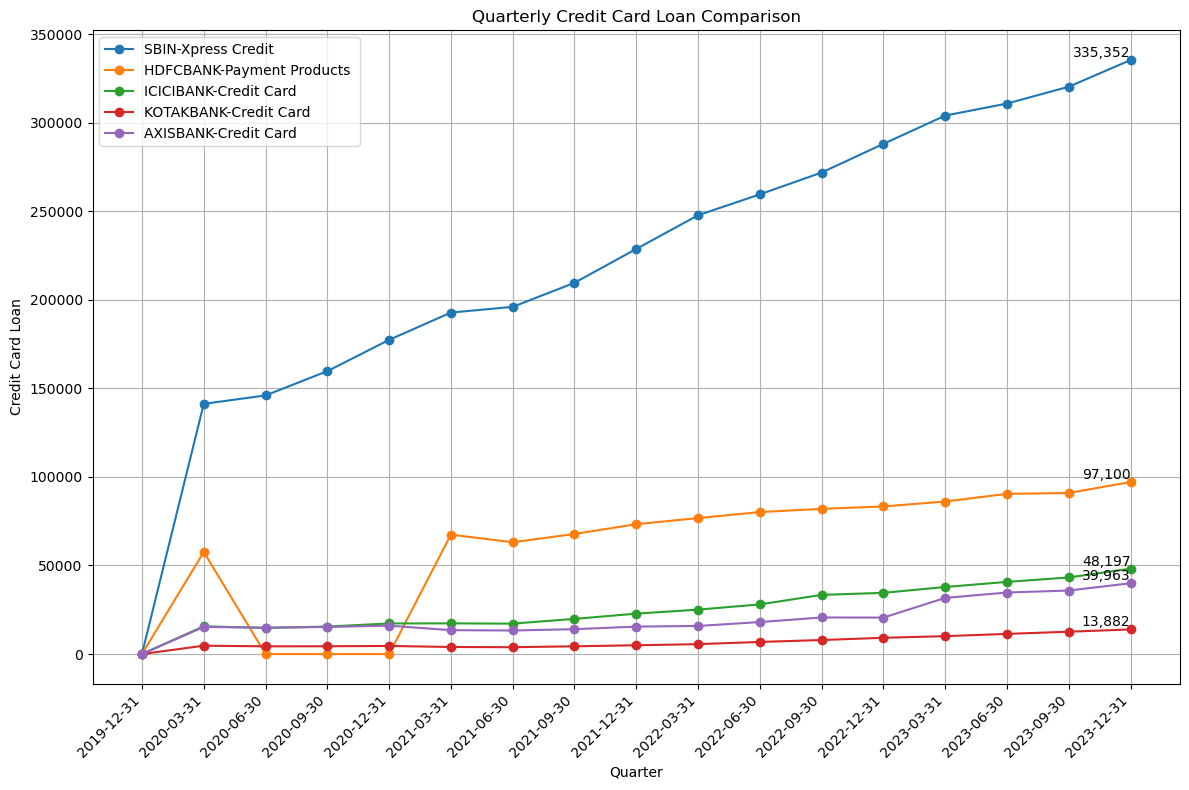

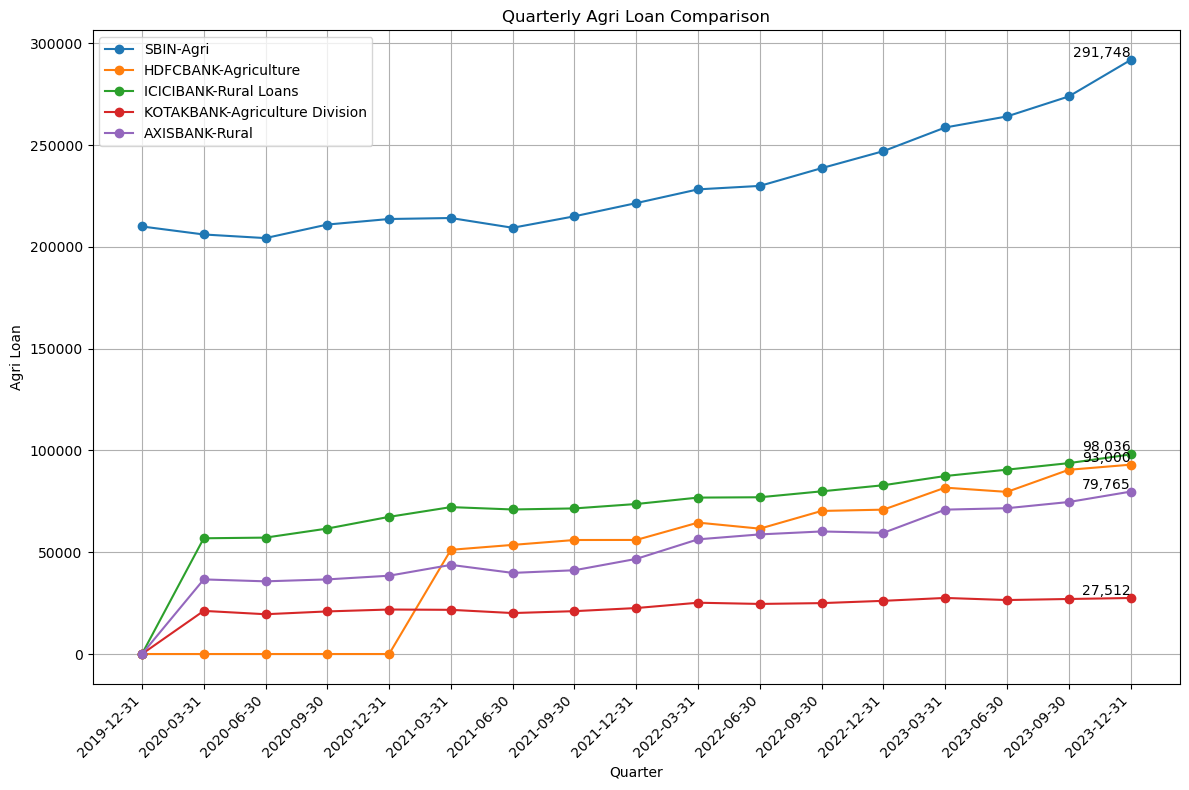

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import locale
from IPython.display import display, Markdown
from datetime import datetime

# Set the locale for formatting
#locale.setlocale(locale.LC_ALL, '')
locale.setlocale(locale.LC_ALL, 'en_IN')  # Indian English locale

# Define the file paths for TCS, ticker2, ticker3, and ticker4
ticker1 = 'SBIN'
ticker2 = 'HDFCBANK'  # Leave blank if not provided
ticker3 = 'ICICIBANK'  # Leave blank if not provided
ticker4 = 'KOTAKBANK'  # Leave blank if not provided
ticker5 = 'AXISBANK'  # Leave blank if not provided
ticker6 = 'INDUSINDBK'  # Leave blank if not provided
# Start column and end column
startColumn = 1  # Default 1
endColumn = 18  # Default 18

RetailLoans = 331
CorporateLoans = 346
HomeLoans = 334
PersonalLoans = 332
GoldLoans = 337
AutoLoans = 333
CreditCardLoan = 335
AgricultureLoan = 345

# Specify whether to plot a bar chart (True) or a line chart (False)
plot_bar_chart = False

file_path_ticker1 = r'C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\QuarterResultsScreenerExcels\2025Q1\{}_FY25Q1.xlsx'.format(ticker1)

# Read the Excel file into a dataframe for ticker1
df_ticker1 = pd.read_excel(file_path_ticker1, sheet_name='QuarterP&L')

# Extract cell values for x-axis (dates) from the dataframe for ticker1
dates = df_ticker1.iloc[1, startColumn:endColumn]
dates = [str(date.date()) for date in dates]  # Convert dates to strings in desired format

# Define the row numbers for each combination of Geographical and Segment Revenue for each ticker
combinations = {
    "Retail Loan%": {
        ticker1: 351,
        ticker2: 350,
        ticker3: 353,
        ticker4: 350,
        ticker5: 350,
        ticker6: 351,
    },
    "Corporate Loan%": {
        ticker1: 359,
        ticker2: 365,
        ticker3: 351,
        ticker4: 360,
        ticker5: 359,
        ticker6: 365,
    },
    "Home Loan%": {
        ticker1: 352,
        ticker2: 353,
        ticker3: 354,
        ticker4: 351,
        ticker5: 351,
        ticker6: 361,
    },
    "Personal Loan%": {
        ticker1: 356,
        ticker2: 351,
        ticker3: 357,
        ticker4: 353,
        ticker5: 354,
        ticker6: 363,
    },
    "Auto Loan%": {
        ticker1: 353,
        ticker2: 352,
        ticker3: 355,
        ticker4: 355,
        ticker5: 353,
        ticker6: 352,
    },
    "Credit Card Loan%": {
        ticker1: 354,
        ticker2: 354,
        ticker3: 358,
        ticker4: 354,
        ticker5: 356,
        ticker6: 362,
    },
    "Agri Loan%": {
        ticker1: 350,
        ticker2: 364,
        ticker3: 356,
        ticker4: 356,
        ticker5: 352,
        ticker6: 358,
    },
#     "Gold Loan%": {
#         ticker1: 355,
#         ticker2: 356,
#         ticker3: 361, #Not available
#         ticker4: 362, #Not available
#         ticker5: 360, #Not available
#         ticker6: 364,
#     },
    "Retail Loan": {
        ticker1: 332,
        ticker2: 331,
        ticker3: 334,
        ticker4: 331,
        ticker5: 331,
        ticker6: 331,
    },
    "Corporate Loan": {
        ticker1: 340,
        ticker2: 346,
        ticker3: 332,
        ticker4: 341,
        ticker5: 340,
        ticker6: 345,
    },
    "Home Loan": {
        ticker1: 333,
        ticker2: 334,
        ticker3: 335,
        ticker4: 332,
        ticker5: 332,
        ticker6: 341,
    },
    "Personal Loan": {
        ticker1: 337,
        ticker2: 332,
        ticker3: 338,
        ticker4: 334,
        ticker5: 335,
        ticker6: 343,
    },
    "Auto Loan": {
        ticker1: 334,
        ticker2: 333,
        ticker3: 336,
        ticker4: 336,
        ticker5: 334,
        ticker6: 332,
    },
    "Credit Card Loan": {
        ticker1: 335,
        ticker2: 335,
        ticker3: 339,
        ticker4: 335,
        ticker5: 337,
        ticker6: 342,
    },
    "Agri Loan": {
        ticker1: 331,
        ticker2: 345,
        ticker3: 337,
        ticker4: 337,
        ticker5: 333,
        ticker6: 338,
    },
#     "Gold Loan": {
#         ticker1: 336,
#         ticker2: 337, 
#         ticker3: 342, #Not available
#         ticker4: 343, #Not available
#         ticker5: 341, #Not available
#         ticker6: 5,
#     },
    # Add more combinations as needed
}

# Display the Markdown-formatted text
display(Markdown("## **Quarterly Loan Segment Numbers**"))

# Specify whether to plot a bar chart (True) or a line chart (False)
plot_bar_chart = False

# Loop through each combination
for combination_name, combination_rows in combinations.items():
    # Plot the charts for the current combination
    plt.figure(figsize=(12, 8))  # Adjust the figure size
    
    for ticker, row_number in combination_rows.items():
        if ticker == '' or ticker is None:
            continue
        
        # Get the file path for the current ticker
        file_path_ticker = r'C:\MyDocuments\03Business\05ResearchAndAnalysis\StockInvestments\QuarterResultsScreenerExcels\2025Q1\{}_FY25Q1.xlsx'.format(ticker)
        df_ticker = pd.read_excel(file_path_ticker, sheet_name='QuarterP&L')
        
        # Extract cell values for y-axis (Revenue)
        revenue = df_ticker.iloc[row_number, startColumn:endColumn].fillna(0).astype(float)
        row_name = df_ticker.iloc[row_number, 0]
        
        plt.plot(dates, revenue, marker='o', linestyle='-', label=ticker + '-' + row_name)
        
        # Displaying only the last value on the chart with appropriate rounding
        last_value = revenue.iloc[-1]
        if last_value < 1:
            last_value_formatted = "{:.4f}".format(last_value)  # Format to 4 decimal places
        elif last_value > 100:
            last_value_formatted = locale.format_string("%.0f", last_value, grouping=True)
        else:
            last_value_formatted = "{:.2f}".format(last_value)  # Format to 2 decimal places
        
        plt.text(dates[-1], last_value, last_value_formatted, ha='right', va='bottom')
    
    plt.title('Quarterly ' + combination_name + ' Comparison')
    plt.xlabel('Quarter')
    plt.ylabel(combination_name)
    plt.xticks(rotation=45, ha='right')  # Adjust rotation and alignment of x-axis labels
    plt.legend()  # Show legend
    plt.grid(True)
    plt.tight_layout()
    plt.show()
